# Chemical Equilbrium Problem

$$
\newcommand{\stst}{^\circ}
\newcommand{\MolarGibbsFreeEnergy}[1][i]{\mu_{#1}\stst}
\newcommand{\AmountOfSubstance}[1][i]{n_{#1}}
\newcommand{\TotalAmountOfSubstance}{n}
\newcommand{\UniversalGasConstant}{R}
\newcommand{\Temperature}{T}
\newcommand{\Pressure}{p}
\newcommand{\StandardPressure}{p\stst}
\newcommand{\WeightElementInSpecies}[2]{a_{#1#2}}
\newcommand{\WeightElement}[1][i]{b_{#1}}
\newcommand{\SetElements}{E}
\newcommand{\SetCompounds}{C}
$$

Substituting $c_i = \MolarGibbsFreeEnergy[i] / \UniversalGasConstant\Temperature + \ln \Pressure/\StandardPressure$ the followig formulation solves the chemical equilibrium problem for ideal gases
$$
\begin{aligned}
    \min 
        &\quad \sum_{i \in \SetCompounds} c_i \AmountOfSubstance + 
            \AmountOfSubstance \ln{\frac{\AmountOfSubstance} {\TotalAmountOfSubstance}} \\
    \text{s.t.} 
        &\quad \sum_{j \in \SetCompounds } \WeightElementInSpecies{i}{j} \AmountOfSubstance[j] = \WeightElement[i] \quad \forall i \in \SetElements \\
        &\quad \sum_{i \in \SetCompounds } \AmountOfSubstance[i] = \TotalAmountOfSubstance
\end{aligned}
$$

## Seam-Methane reforming

$$
\begin{align}
    \ce{CH4 + H2O &<=> CO + 3H2} \tag{I}\\
    \ce{CO + H2O &<=> CO2 + H2} \tag{II}\\
    \ce{CH4 + 2 H2O &<=> CO2 + 4H2} \tag{III}
\end{align}
$$

In [2]:
from enum import Enum
import os
from datetime import datetime
from pathlib import Path

from IPython.display import Image

from phdtools import DATA_DIR, RESULTS_DIR, PROJECT_ROOT, TMP_DIR
from phdtools.rdm import DataID, DataType, Chapter, auto_create_path, write_metadata
from phdtools.data.constants import GAS_CONST_SI

TODAY = datetime.today().strftime("%y%m%d")
FILE_DATE = os.getenv("FILE_DATE", "260407")

overwrite = False
if overwrite:
    FILE_DATE = TODAY

### Material Properties

*For the determination of equilibrium composition, the only specie property needed is the molal standard (Gibbs) free energy function $F^\circ /RT$. This function
is obtained directly from tables or easily derived from the more commonly tabulated function* $(F^\circ - E_0^\circ) / T$. [(White, Johnson and Dantzig, 1958)](#References)

#### NIST-JANAF Thermochemical Tables 4th edition [(Allison, 2013)](#References)
Enthalpy Reference Temperature = 298.15 K <br>
Standard State Pressure = 0.1 MPa = 1 bar <br>

Quelle: https://janaf.nist.gov/

To initialize the local thermo-chemical database run
```shell
python "../../scripts/thermotables.py" --no-local -d "{DATA_DIR}/nist-janaf" --file-index "{DATA_DIR}/nist-janaf/file_index.csv"
```

Then create a `VIEW` of the standard Gibbs free energy. 
This is computed following [White, Johnson and Dantzig (1958)](#References) and [Gordon and Mcbride (1994)](#References)
```shell
sqlite3 "{DATA_DIR}/nist-janaf/nist_janaf_thermochemical_tables.sqlite" < "queries/view_std_gibbs_free_energy.sql"
```

This already be done as part of the installation. 

In [3]:
import sqlite3
import pandas as pd

In [4]:
with sqlite3.connect(
    DATA_DIR / "nist-janaf" / "nist_janaf_thermochemical_tables.sqlite"
) as con:
    query = "SELECT COUNT(*) FROM sqlite_master WHERE type='view' AND name='std_gibbs_free_energy'"
    cur = con.cursor()
    res = cur.execute(query)
    (has_view,) = res.fetchone()
    if not has_view:
        with open("queries/view_std_gibbs_free_energy.sql", "r") as f:
            query = f.read()
        cur.execute(query)

In [5]:
query = """
SELECT * FROM [std_gibbs_free_energy]
WHERE "T(K)" BETWEEN 600 AND 1600
AND "FORMULA" IN ("C1H4(g)", "C1O1(g)", "C1O2(g)", "H2(ref)", "H2O1(g)")
;
"""
with sqlite3.connect(
    DATA_DIR / "nist-janaf" / "nist_janaf_thermochemical_tables.sqlite"
) as con:
    stdGibbsFreeEnergy = pd.read_sql(query, con).pivot(
        index="T(K)", columns="FORMULA", values="G"
    )

In [6]:
stdGibbsFreeEnergy.head()

FORMULA,C1H4(g),C1O1(g),C1O2(g),H2(ref),H2O1(g)
T(K),,,,,
600.0,-191.3348,-232.5760,-526.5852,-81.8352,-359.1560
700.0,-213.3610,-254.6500,-551.2936,-97.1754,-380.7515
800.0,-236.2130,-277.1710,-576.7108,-112.9368,-402.8836
900.0,-259.8518,-300.0922,-602.7720,-129.0699,-425.5016
1000.0,-284.2430,-323.3750,-629.4230,-145.5360,-448.5640


In [7]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 1)

query = """
SELECT * FROM [std_gibbs_free_energy]
WHERE "T(K)" BETWEEN 600 AND 1600
AND "FORMULA" IN ("C1H4(g)", "C1O1(g)", "C1O2(g)", "H2(ref)", "H2O1(g)")
;
"""
with sqlite3.connect(
    DATA_DIR / "nist-janaf" / "nist_janaf_thermochemical_tables.sqlite"
) as con:
    stdGibbsFreeEnergy = pd.read_sql(query, con).pivot(
        index="T(K)", columns="FORMULA", values="G"
    )


@auto_create_path
def save_gibbs_feee_energy(path, frame=stdGibbsFreeEnergy):

    description = (
        "Standard Gibbs free energy vs. temperature T. \n"
        "Computed following White, Johnson and Dantzig (1958) and Gordon and Mcbride (1994)\n"
        "taking tabulated data from Allison (2013)\n"
        "\n"
        "References:\n"
        "-----------\n"
        'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
        "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n\n"
        'White, W.B., Johnson, S.M. and Dantzig, G.B. (1958) "Chemical Equilibrium in Complex Mixtures", \n'
        "The Journal of Chemical Physics, 28(5), pp. 751–755. Available at: https://doi.org/10.1063/1.1744264.\n\n"
        "Gordon, S. and Mcbride, B.J. (1994) Computer program for calculation of complex chemical equilibrium \n"
        "compositions and applications. Part 1: Analysis. Available at: https://ntrs.nasa.gov/citations/19950013764.\n"
    )
    fname = path / f"{TODAY}_std_gibbs_energy.csv"
    with open(fname, "w") as f:
        write_metadata(f, description)
        frame.to_csv(f)


save_gibbs_feee_energy(
    data_id,
    doc=r"Standard Gibbs free energy vs. temperature. Data taken from \textcite{Allison.2013a}",
    frame=stdGibbsFreeEnergy,
)

In [8]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 1).get_path(fail_exists=False)}

260407_std_gibbs_energy.csv


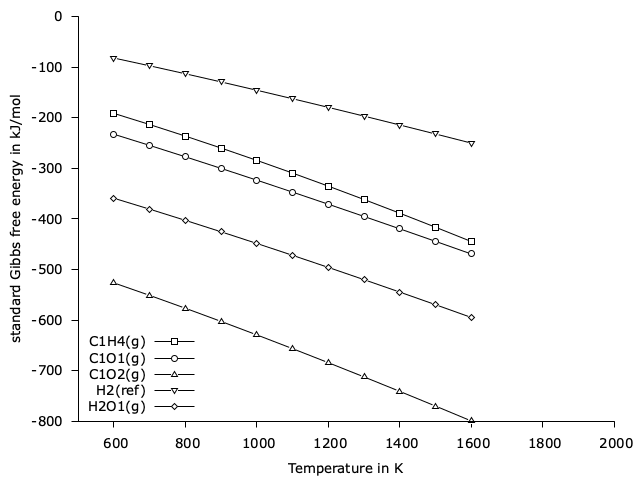

In [9]:
tmp = (
    DataID(DataType.FIGURE, Chapter.UNUSED, 1).get_path(fail_exists=False)
    / f"{FILE_DATE}_std_gibbs_energy.csv"
)
!gnuplot -e "filename='{tmp}'; call 'plot_240320_std_free_energy_nist_janaf.gnu'"
del tmp
Image("./plots/240701_std_free_energy_nist_janaf.png")

##### Interpolate between given values

In [10]:
import numpy as np

temp = 710

if not temp in stdGibbsFreeEnergy.index:
    stdGibbsFreeEnergy.loc[temp, :] = np.nan
    stdGibbsFreeEnergy = stdGibbsFreeEnergy.sort_index().interpolate(method="index")
stdGibbsFreeEnergy.loc[temp]

FORMULA
C1H4(g)   -215.64620
C1O1(g)   -256.90210
C1O2(g)   -553.83532
H2(ref)    -98.75154
H2O1(g)   -382.96471
Name: 710.0, dtype: float64

In [11]:
stdGibbsFreeEnergy.head()

FORMULA,C1H4(g),C1O1(g),C1O2(g),H2(ref),H2O1(g)
T(K),,,,,
600.0,-191.3348,-232.5760,-526.58520,-81.83520,-359.15600
700.0,-213.3610,-254.6500,-551.29360,-97.17540,-380.75150
710.0,-215.6462,-256.9021,-553.83532,-98.75154,-382.96471
800.0,-236.2130,-277.1710,-576.71080,-112.93680,-402.88360
900.0,-259.8518,-300.0922,-602.77200,-129.06990,-425.50160


#### Pyomo Implementation

In [12]:
%pfile smr.dat

Object `smr.dat` not found.


set SetCompounds := "C1H4(g)" "C1O2(g)" "C1O1(g)" "H2O1(g)" "H2(ref)";
set SetElements := "C" "H" "O";

param number_of_atoms default 0 :=
    [C,*]   "C1H4(g)"   1
            "C1O2(g)"   1
            "C1O1(g)"   1
    [H,*]   "C1H4(g)"   4
            "H2O1(g)"   2
            "H2(ref)"   2
    [O,*]   "C1O2(g)"   2
            "C1O1(g)"   1
            "H2O1(g)"   1
;

param temperature := 600;
param pressure := 40;
param amount_element := 
    "C" 1
    "H" 10
    "O" 3
;

param std_gibbs_free_energy := 
    "C1H4(g)"   -191.3348
    "C1O1(g)"   -232.5760
    "C1O2(g)"   -526.5852
    "H2(ref)"    -81.8352
    "H2O1(g)"   -359.1560
;


In [14]:
%%sh
pyomo solve --solver=ipopt "../../phdtools/models/white_dantzig_1958.py" "smr.dat"

[    0.00] Setting up Pyomo environment
[    0.00] Applying Pyomo preprocessing actions
[    0.00] Creating model
[    0.01] Applying solver
[    0.02] Processing results
    Number of solutions: 1
    Solution Information
      Gap: None
      Status: optimal
      Function Value: -241.93917176231494
    Solver results file: results.yml
[    0.02] Applying Pyomo postprocessing actions

Results for smr.dat; MD5 checksum: fed6b996901a6aa79916ce7486c0d697

	**Parameters**
		Temperature (K):	600
		Pressure (atm):		40
		Steam to carbon ratio:	3.0

	**Mole fractions**
		C1H4(g):	0.24194632409144842
		C1O1(g):	5.552420108060952e-06
		C1O2(g):	0.005363564852259648
		H2(ref):	0.021470916669362825
		H2O1(g):	0.7312136419668209

[    0.02] Pyomo Finished


#### MAiNGO Implementation

In [15]:
!maingo chemical_equilibrium_ideal.txt

zsh:1: command not found: maingo


### Parameter sweep

To build cases run
```shell
case_builder.py --data-base {DATA_DIR}/nist-janaf/nist_janaf_thermochemical_tables.sqlite cases.yml
```

In [16]:
%pfile cases.yml

Object `cases.yml` not found.


temperature:
  start: 600
  stop: 1610
  step: 10
pressure:
  - 1
  - 5
  - 10
  - 20
  - 30
compounds:
  - C1H4(g)
  - C1O1(g)
  - C1O2(g)
  - H2O1(g)
  - H2(ref)
amount_element:
  - C: 1 
    H: 8
    O: 2
  - C: 2 
    H: 18
    O: 5
  - C: 1
    H: 10
    O: 3
  - C: 2 
    H: 25
    O: 6


Compute (initial) amount of element from steam-to-carbon ratio. 

In [17]:
steamToCarbonMolar = 3

amount_element = {
    "C": 1,
    "H": 4 + 2 * steamToCarbonMolar,
    "O": steamToCarbonMolar,
}
amount_element

{'C': 1, 'H': 10, 'O': 3}

In [18]:
# Xu and Froment
steamToMethaneMolar = 3
hydrogenToMethaneMolar = 1.25

amount_element = {
    "C": 2,
    "H": 2 * (4 + 2 * steamToMethaneMolar + 2 * hydrogenToMethaneMolar) * 1,
    "O": 2 * steamToMethaneMolar * 1,
}
amount_element

{'C': 2, 'H': 25.0, 'O': 6}

Use `run.sh` to build and run cases as specified in `cases.yml`. 
Use `add.sh` to add entries to a `pyoptdb` database. 

In [19]:
# Skipped if a pyoptdb.sqlite3 file exists. Assumes the database contains the results
if not os.path.exists(".pyoptdb/pyoptdb.sqlite3"):
    tmpdir = TMP_DIR / "chemical_equilibrium_runs"

    if not os.path.exists(tmpdir):
        os.makedirs(tmpdir)

        !source ./run.sh

        if not os.path.exists(".pyoptdb/pyoptdb.sqlite3"):
            !pyoptdb init

        !source ./add.sh

running case builder...
...done!
/Users/marvinmeck/test/phd-tools-dev/notebooks/fuel-processing
solving...
1/    2020
2/    2020
3/    2020
4/    2020
5/    2020
6/    2020
7/    2020
8/    2020
9/    2020
10/    2020
11/    2020
12/    2020
13/    2020
14/    2020
15/    2020
16/    2020
17/    2020
18/    2020
19/    2020
20/    2020
21/    2020
22/    2020
23/    2020
24/    2020
25/    2020
26/    2020
27/    2020
28/    2020
29/    2020
30/    2020
31/    2020
32/    2020
33/    2020
34/    2020
35/    2020
36/    2020
37/    2020
38/    2020
39/    2020
40/    2020
41/    2020
42/    2020
43/    2020
44/    2020
45/    2020
46/    2020
47/    2020
48/    2020
49/    2020
50/    2020
51/    2020
52/    2020
53/    2020
54/    2020
55/    2020
56/    2020
57/    2020
58/    2020
59/    2020
60/    2020
61/    2020
62/    2020
63/    2020
64/    2020
65/    2020
66/    2020
67/    2020
68/    2020
69/    2020
70/    2020
71/    2020
72/    2020
73/    2020
74/    2020
75/    2020
76

### Plots

In [20]:
DBFILE = Path(".pyoptdb/pyoptdb.sqlite3")

In [21]:
with sqlite3.connect(DBFILE) as con:
    query = (
        "SELECT COUNT(*) FROM sqlite_master WHERE type='view' AND name='mole_fractions'"
    )
    cur = con.cursor()
    res = cur.execute(query)
    (has_view,) = res.fetchone()
    if not has_view:
        with open("queries/view_mole_fractions.sql", "r") as f:
            query = f.read()
        cur.execute(query)

In [22]:
import sqlite3

with sqlite3.connect(DBFILE) as con:
    cur = con.cursor()
    cur.execute("SELECT DISTINCT hydrogen_to_carbon_molar from [mole_fractions]")

cur.fetchall()

[(8.0,), (9.0,), (10.0,), (12.5,)]

#### Equilibrium composition as a function of Temperature

In [23]:
data_id = DataID(DataType.FIGURE, Chapter.METHODS, 4)

query = """
SELECT
    temperature_kelvin AS 'T(K)',
    compound AS COMPOUND,
    mole_fraction AS x
FROM 
    [mole_fractions] 
WHERE 
    oxygen_to_carbon_molar = 3
AND 
    hydrogen_to_carbon_molar = 12.5
AND 
    pressure_bar = 10
AND
    temperature_kelvin BETWEEN 600 AND 1600
AND 
    temperature_kelvin % 20 = 0
ORDER BY temperature_kelvin
;
"""


@auto_create_path
def save_steam_methane_reforming_equilibrium(path, query):

    with sqlite3.connect(DBFILE) as con:
        df = pd.read_sql(query, con).pivot_table(
            index="T(K)", columns="COMPOUND", values="x"
        )  # TODO handle duplicates

    description = (
        (
            "Equilibrium mole fraction over temperature T in Kelvin\n"
            "determined via direct Gibbs free energy minimization, see White, Johnson and Dantzig (1958).\n"
            "Values for the standard (molar) Gibbs free energy were computed as outlined in \n"
            "White, Johnson and Dantzig (1958) and  Gordon and Mcbride (1994, p. 19) using \n"
            "property data from Allison (2013), interpolating linearly between temperature values.\n"
            "\n"
            f"Database {DBFILE.resolve()}\n"
            "\n"
            "Query:\n"
        )
        + "\n".join(f"  {line}" for line in query.strip().split("\n"))
        + (
            "\n\n"
            "References:\n"
            "-----------\n"
            'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
            "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n\n"
            'White, W.B., Johnson, S.M. and Dantzig, G.B. (1958) "Chemical Equilibrium in Complex Mixtures", \n'
            "The Journal of Chemical Physics, 28(5), pp. 751–755. Available at: https://doi.org/10.1063/1.1744264.\n\n"
            "Gordon, S. and Mcbride, B.J. (1994) Computer program for calculation of complex chemical equilibrium \n"
            "compositions and applications. Part 1: Analysis. Available at: https://ntrs.nasa.gov/citations/19950013764.\n"
        )
    )

    fname = path / f"{TODAY}_SMR_Equilibrium.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description)
        df.to_csv(f, index=True)


save_steam_methane_reforming_equilibrium(
    data_id,
    doc=r"Equilibrium mole fractions vs. temperature, determined via direct Gibbs free energy minimization; see \textcite{White.1958a}",
    query=query,
    overwrite=overwrite,
)

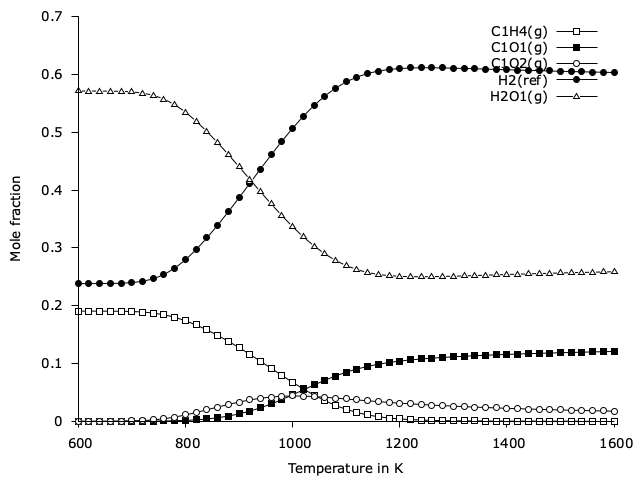

In [24]:
tmp = (
    DataID(DataType.FIGURE, Chapter.METHODS, 4).get_path(fail_exists=False)
    / f"{FILE_DATE}_SMR_Equilibrium.csv"
)
!gnuplot -e "filename='{tmp}'; call 'plot_240405_chemical_equilibrium.gnu'"
del tmp
Image("plots/plot_240405_chemical_equilibrium.png")

#### Equilibrium composition as a function of temperature and pressure

In [25]:
!sqlite3 -separator ',' {DBFILE} "SELECT DISTINCT pressure_bar from mole_fractions"

1.0
5.0
10.0
20.0
30.0


In [26]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 2)

query = """
SELECT
    temperature_kelvin AS 'T(K)',
    pressure_bar AS 'p(bar)',
    mole_fraction AS 'x'
FROM mole_fractions 
WHERE 
    oxygen_to_carbon_molar = 2
AND 
    hydrogen_to_carbon_molar = 8
AND compound LIKE 'H2(ref)'
AND temperature_kelvin BETWEEN 600 AND 1600
AND pressure_bar IN (10,20,30)
;
"""


@auto_create_path
def save_smr_equilibrium_hydrogen_pressure(path, query):

    description = (
        (
            "Equilibrium mole fraction of hydrogen over temperature T in Kelvin, for different values of pressure.\n"
            "determined via direct Gibbs free energy minimization, see White, Johnson and Dantzig (1958).\n"
            "Values for the standard (molar) Gibbs free energy were computed as outlined in \n"
            "White, Johnson and Dantzig (1958) and  Gordon and Mcbride (1994, p. 19) using \n"
            "property data from Allison (2013), interpolating linearly between temperature values.\n"
            "\n"
            f"Database {DBFILE.resolve()}\n"
            "\n"
            "Query:\n"
        )
        + "\n".join(f"  {line}" for line in query.strip().split("\n"))
        + (
            "\n\n"
            "References:\n"
            "-----------\n"
            'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
            "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n\n"
            'White, W.B., Johnson, S.M. and Dantzig, G.B. (1958) "Chemical Equilibrium in Complex Mixtures", \n'
            "The Journal of Chemical Physics, 28(5), pp. 751–755. Available at: https://doi.org/10.1063/1.1744264.\n\n"
            "Gordon, S. and Mcbride, B.J. (1994) Computer program for calculation of complex chemical equilibrium \n"
            "compositions and applications. Part 1: Analysis. Available at: https://ntrs.nasa.gov/citations/19950013764.\n"
        )
    )

    with sqlite3.connect(DBFILE) as con:
        df = pd.read_sql(query, con).pivot_table(
            index="T(K)", columns="p(bar)", values="x"
        )  # TODO handle duplicates

    fname = path / f"{TODAY}_smr_xH2_over_T_free_p_meck.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description=description)
        df.to_csv(f, index=True)


save_smr_equilibrium_hydrogen_pressure(
    data_id,
    doc=r"Equilibrium mole fraction of hydrogen vs. temperature for different values of pressure, determined via direct Gibbs free energy minimization; see \textcite{White.1958a}",
    query=query,
    overwrite=overwrite,
)

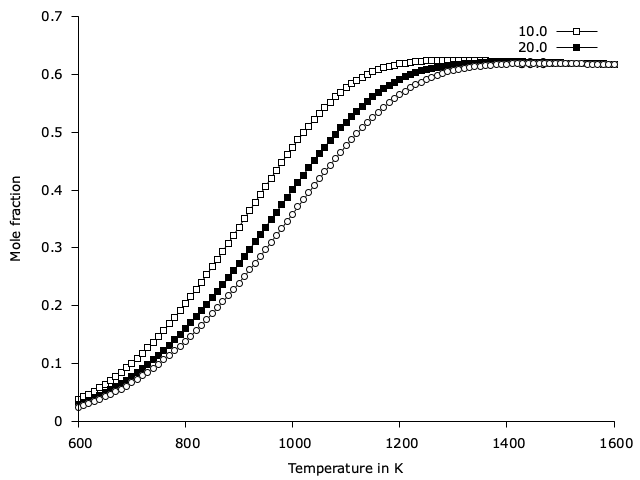

In [27]:
tmp = (
    DataID(DataType.FIGURE, Chapter.UNUSED, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_smr_xH2_over_T_free_p_meck.csv"
)
!gnuplot -e "filename='{tmp}'; call 'plot_240405_chemical_equilibrium.gnu'"
del tmp
Image("plots/plot_240405_chemical_equilibrium.png")

#### Equilibrium composition as a function of temperature and steam-to-carbon ratio

In [28]:
!sqlite3 -separator ',' {DBFILE} "SELECT DISTINCT oxygen_to_carbon_molar from mole_fractions"

2.0
2.5
3.0


In [29]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 3)

query = """
SELECT
    temperature_kelvin AS 'T(K)', 
    oxygen_to_carbon_molar AS 'S/C',
    mole_fraction AS 'x'
FROM 
    mole_fractions 
WHERE 
    pressure_bar = 10
AND 
    compound LIKE 'H2(ref)'
AND 
    temperature_kelvin BETWEEN 600 AND 1600
AND 
    oxygen_to_carbon_molar IN (2.0,2.5,3.0)
AND 
    ABS( hydrogen_to_carbon_molar - (2 * oxygen_to_carbon_molar + 4) ) < 1e-6 
;
"""


@auto_create_path
def save_smr_equilibrium_hydrogen_steam_to_carbon(path, query):

    description = (
        (
            "Equilibrium mole fraction of hydrogen over temperature T in Kelvin, for different values of steam-to-carbon ratio.\n"
            "determined via direct Gibbs free energy minimization, see White, Johnson and Dantzig (1958).\n"
            "Values for the standard (molar) Gibbs free energy were computed as outlined in \n"
            "White, Johnson and Dantzig (1958) and  Gordon and Mcbride (1994, p. 19) using \n"
            "property data from Allison (2013), interpolating linearly between temperature values.\n"
            "\n"
            f"Database {DBFILE.resolve()}\n"
            "\n"
            "Query:\n"
        )
        + "\n".join(f"  {line}" for line in query.strip().split("\n"))
        + (
            "\n\n"
            "References:\n"
            "-----------\n"
            'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
            "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n\n"
            'White, W.B., Johnson, S.M. and Dantzig, G.B. (1958) "Chemical Equilibrium in Complex Mixtures", \n'
            "The Journal of Chemical Physics, 28(5), pp. 751–755. Available at: https://doi.org/10.1063/1.1744264.\n\n"
            "Gordon, S. and Mcbride, B.J. (1994) Computer program for calculation of complex chemical equilibrium \n"
            "compositions and applications. Part 1: Analysis. Available at: https://ntrs.nasa.gov/citations/19950013764.\n"
        )
    )

    with sqlite3.connect(DBFILE) as con:
        df = pd.read_sql(query, con).pivot_table(
            index="T(K)", columns="S/C", values="x"
        )  # TODO handle duplicates

    fname = path / f"{TODAY}_smr_xH2_over_T_free_sc_meck.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description)
        df.to_csv(f, index=True)


save_smr_equilibrium_hydrogen_steam_to_carbon(
    data_id,
    doc=r"Equilibrium mole fraction of hydrogen vs. temperature for different values of steam-to-carbon ratio, determined via direct Gibbs free energy minimization; see \textcite{White.1958a}",
    query=query,
    overwrite=overwrite,
)

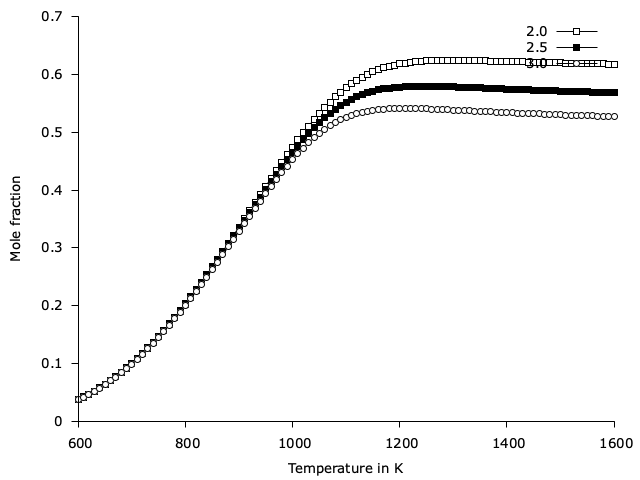

In [30]:
tmp = (
    DataID(DataType.FIGURE, Chapter.UNUSED, 3).get_path(fail_exists=False)
    / f"{FILE_DATE}_smr_xH2_over_T_free_sc_meck.csv"
)
!gnuplot -e "filename='{tmp}'; call 'plot_240405_chemical_equilibrium.gnu'"
del tmp
Image("plots/plot_240405_chemical_equilibrium.png")

### Validation

#### Equilibrium constant(s)

In [31]:
idxReaction = Enum("idxReactinon", ["SMR", "WGS", "DSR"], start=0)
idxCompound = Enum(
    "idxCompound", ["C1H4(g)", "H2O1(g)", "C1O1(g)", "H2(ref)", "C1O2(g)"], start=0
)

$$
\begin{align}
    \ce{CH4 + H2O &<=> CO + 3H2}\tag{I}\\
    \ce{CO + H2O &<=> CO2 + H2}\tag{II}\\
    \ce{CH4 + 2 H2O &<=> CO2 + 4H2}\tag{III}
\end{align}
$$

In [32]:
stoichiometricNumber = pd.DataFrame(
    index=[c.name for c in idxCompound],
    columns=[r.name for r in idxReaction],
    data={
        "SMR": {"C1H4(g)": -1, "H2O1(g)": -1, "C1O1(g)": 1, "H2(ref)": 3, "C1O2(g)": 0},
        "WGS": {"C1H4(g)": 0, "H2O1(g)": -1, "C1O1(g)": -1, "H2(ref)": 1, "C1O2(g)": 1},
        "DSR": {"C1H4(g)": -1, "H2O1(g)": -2, "C1O1(g)": 0, "H2(ref)": 4, "C1O2(g)": 1},
    },
)

In [33]:
from phdtools.data.thermochemical import get_logEquilibriumConst

logEquilibriumConst = get_logEquilibriumConst(
    Tmin=600, Tmax=1600, reactions={"SMR", "WGS", "DSR"}
)
logEquilibriumConst.head()

,WGS,SMR,DSR
T(K),,,
600.0,3.345376,-14.514468,-11.169092
700.0,2.245313,-8.236423,-5.991110
800.0,1.442216,-3.474969,-2.032753
900.0,0.835091,0.260456,1.095548
1000.0,0.363343,3.268642,3.631985


In [34]:
with sqlite3.connect(DBFILE) as con:
    query = "SELECT COUNT(*) FROM sqlite_master WHERE type='view' AND name='reaction_quotients'"
    cur = con.cursor()
    res = cur.execute(query)
    (has_view,) = res.fetchone()
    if not has_view:
        with open("queries/view_reaction_quotients.sql", "r") as f:
            query = f.read()
        cur.execute(query)

In [35]:
query = """
SELECT
    temperature_kelvin AS "T(K)",
    pressure_bar AS "p(bar)",
    "log Q1* (SR)" AS "log Q1*",
    "log Q2* (WGS)" AS "log Q2*",
    "log Q3* (DSR)" AS "log Q3*"
FROM 
    [reaction_quotients]
WHERE
    temperature_kelvin BETWEEN 600 AND 1600
AND 
    MOD(temperature_kelvin, 100) = 0
AND
    pressure_bar IN (5,10,20,30,40)
AND
    oxygen_to_carbon_molar = 2
AND 
    hydrogen_to_carbon_molar = 8
;
"""

with sqlite3.connect(DBFILE) as con:
    logReactionQuotients = pd.read_sql(query, con).pivot_table(
        index="T(K)", columns="p(bar)", values=["log Q1*", "log Q2*", "log Q3*"]
    )

In [36]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 4)


@auto_create_path
def save_validation_equilibrium_constants(
    path,
    logEquilibriumConst=logEquilibriumConst,
    logReactionQuotients=logReactionQuotients,
):
    description = (
        (
            "Reaction quotients Q for steam-methane reforming (1), water-gas shift (2), and direct steam reforming (3).\n"
            "determined via direct Gibbs free energy minimization, see White, Johnson and Dantzig (1958).\n"
            "Values for the standard (molar) Gibbs free energy were computed as outlined in \n"
            "White, Johnson and Dantzig (1958) and  Gordon and Mcbride (1994, p. 19) using \n"
            "property data from Allison (2013), interpolating linearly between temperature values.\n"
            "\n"
            f"Database {DBFILE.resolve()}\n"
            "\n"
            "Query:\n"
        )
        + "\n".join(f"  {line}" for line in query.strip().split("\n"))
        + (
            "\n\n"
            "References:\n"
            "-----------\n"
            'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
            "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n\n"
            'White, W.B., Johnson, S.M. and Dantzig, G.B. (1958) "Chemical Equilibrium in Complex Mixtures", \n'
            "The Journal of Chemical Physics, 28(5), pp. 751–755. Available at: https://doi.org/10.1063/1.1744264.\n\n"
            "Gordon, S. and Mcbride, B.J. (1994) Computer program for calculation of complex chemical equilibrium \n"
            "compositions and applications. Part 1: Analysis. Available at: https://ntrs.nasa.gov/citations/19950013764.\n"
        )
    )

    fname = path / f"{TODAY}_reaction_quotients_meck.csv"
    with open(fname, "w") as f:
        write_metadata(f, description)
        logReactionQuotients.to_csv(f, index=True)

    description = (
        "Equilibrium constants K for steam-methane reforming (1), water-gas shift (2), and direct steam reforming (3).\n"
        "calculated from the Gibbs free reaction enthalpy (see Atkins, 2023).\n"
        "taking values for the Gibbs free formation energy from Allison (2013).\n"
        "\n"
        "References:\n"
        "-----------\n"
        'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
        "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n\n"
        "Atkins, P.W., Paula, J.D. and Keeler, J. (2023) Atkins' Physical chemistry. Twelfth edition.\n"
        "    New York NY: Oxford University Press.\n"
    )

    fname = path / f"{TODAY}_equilibrium_constants_meck.csv"
    with open(fname, "w") as f:
        write_metadata(f, description)
        logEquilibriumConst.to_csv(f, header=["log K1", "log K2", "log K3"], index=True)


save_validation_equilibrium_constants(
    data_id,
    doc=r"Reaction quotients determined via direct Gibbs free energy minimization and equilibrium constants calculated from the Gibbs free reaction energy vs. temperature",
    overwrite=overwrite,
)

In [37]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 4).get_path(fail_exists=False)}

260407_equilibrium_constants_meck.csv 260407_reaction_quotients_meck.csv


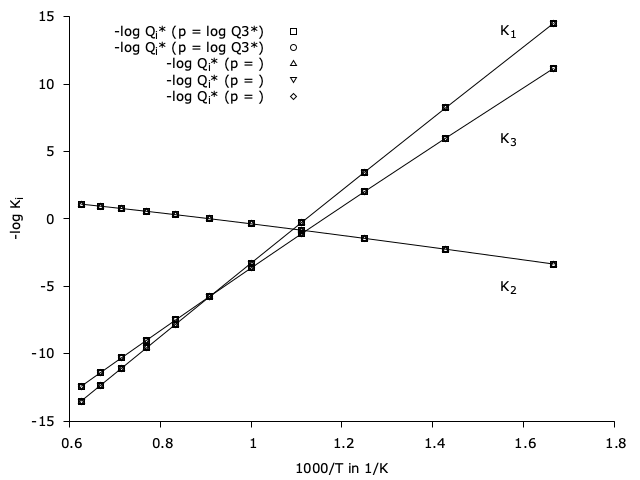

In [38]:
f1 = (
    DataID(DataType.FIGURE, Chapter.UNUSED, 4).get_path(fail_exists=False)
    / f"{FILE_DATE}_equilibrium_constants_meck.csv"
)
f2 = (
    DataID(DataType.FIGURE, Chapter.UNUSED, 4).get_path(fail_exists=False)
    / f"{FILE_DATE}_reaction_quotients_meck.csv"
)

!gnuplot -e "filename1='{f1}'; filename2='{f2}'; call 'plot_240820_equlibrium_const.gnu'"

del f1
del f2

Image("plots/plot_240820_equlibrium_const.png")

#### Approximation error

In [39]:
minTemp, maxTemp = 600, 1600
delta1 = 100 * np.abs(
    (
        np.exp(logReactionQuotients.loc[minTemp:maxTemp]["log Q1*"])
        - np.exp(
            logEquilibriumConst.loc[minTemp:maxTemp]["SMR"].to_numpy()[:, np.newaxis]
        )
    )
    / np.exp(logEquilibriumConst.loc[minTemp:maxTemp]["SMR"].to_numpy())[:, np.newaxis]
)
delta2 = 100 * np.abs(
    (
        np.exp(logReactionQuotients.loc[minTemp:maxTemp]["log Q2*"])
        - np.exp(
            logEquilibriumConst.loc[minTemp:maxTemp]["WGS"].to_numpy()[:, np.newaxis]
        )
    )
    / np.exp(logEquilibriumConst.loc[minTemp:maxTemp]["WGS"].to_numpy())[:, np.newaxis]
)
delta3 = 100 * np.abs(
    (
        np.exp(logReactionQuotients.loc[minTemp:maxTemp]["log Q3*"])
        - np.exp(
            logEquilibriumConst.loc[minTemp:maxTemp]["DSR"].to_numpy()[:, np.newaxis]
        )
    )
    / np.exp(logEquilibriumConst.loc[minTemp:maxTemp]["DSR"].to_numpy())[:, np.newaxis]
)

percentError = pd.concat(
    [delta1, delta2, delta3], axis=1, keys=["delta1", "delta2", "delta3"]
)

In [40]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 5)


@auto_create_path
def save_percent_error(path, percentError=percentError):
    description = f"Percent error for the difference between reaction quotients from direct Gibbs free energy minimization and equilibrium constant (see {DataID(DataType.FIGURE, Chapter.UNUSED, 4).to_sqid()})"
    fname = path / "{}_percent_error_meck.csv".format(TODAY)
    with open(fname, "w") as f:
        write_metadata(f, description)
        percentError.to_csv(f, index=True)


save_percent_error(
    data_id,
    doc="Percent error for the difference between reaction quotients from direct Gibbs free energy minimization and equilibrium constant",
    overwrite=overwrite,
)

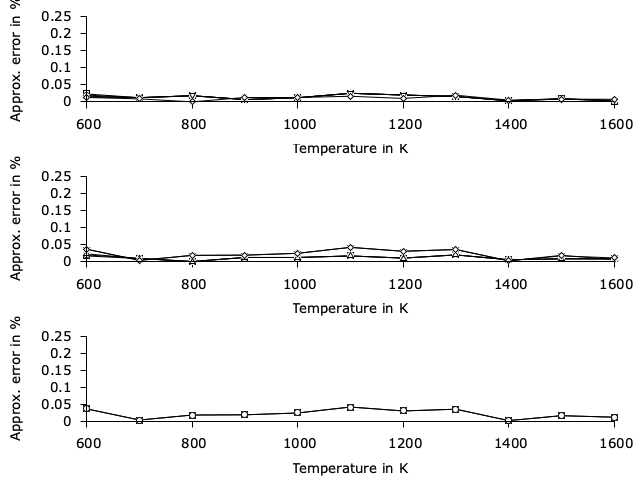

In [41]:
tmp = (
    DataID(DataType.FIGURE, Chapter.UNUSED, 5).get_path(fail_exists=False)
    / f"{FILE_DATE}_percent_error_meck.csv"
)
!gnuplot -e "filename='{tmp}'; call 'plot_240820_percent_error.gnu'"
Image("plots/plot_240820_percent_error.png")

## References
1. White, W. B.; Johnson, S. M.; Dantzig, G. B. (1958): Chemical Equilibrium in Complex Mixtures. In The Journal of Chemical Physics 28 (5), pp. 751–755. DOI: 10.1063/1.1744264.
2. Allison, T. (2013) “NIST-JANAF Thermochemical Tables - SRD 13.” National Institute of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.
3. Gordon, S. and Mcbride, B.J. (1994) Computer program for calculation of complex chemical equilibrium compositions and applications. Part 1: Analysis. Available at: https://ntrs.nasa.gov/citations/19950013764.
4. Atkins, P.W., Paula, J.D. and Keeler, J. (2023) Atkins’ Physical chemistry. Twelfth edition. New York NY: Oxford University Press.
